# Análisis Enriquecido de Charts Musicales



**Week:** 2026-W37 | **Analysis Date:** 2026-09-07


## 1. Introducción

Esta semana, nuestro radar musical ha capturado la energía de 100 canciones que resuenan en 23 países, un crisol sonoro que abarca 15 géneros distintos y que ha generado una conversación global de más de 1.49 mil millones de vistas y 150 millones de likes. No son solo números; son las pulsaciones de una audiencia que no solo escucha, sino que participa activamente. En este informe, desglosamos los patrones ocultos de esta interacción masiva: ¿qué géneros logran la mayor fidelidad y *engagement*, y cómo se comportan las colaboraciones en diferentes territorios? Analizamos las tendencias que dominan en cada país, revelando los sonidos que unen a las comunidades y los que marcan la diferencia. Prepárate para un viaje por los mapas de calor de la popularidad, donde cada dato cuenta una historia sobre el presente y el futuro del consumo musical.

## 2. Configuración y Carga de Datos

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W37_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W37_enriched.db
Tables found: ['enriched_songs']
Loaded 100 songs, 28 columns


,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,16,84086671,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-09-07 18:30:34,2,9.44
1,2,445,Prabha Bangarigalla & Jangi Reddy & Kasarla S...,Yeshanagula,1,49615669,https://www.youtube.com/watch?v=JqFzhcWo3EU,192,3:12,2026-08-29,...,0,3,0,India,Indian Pop,2/3,,2026-09-07 18:30:35,3,1.27
2,3,446,ARJN & Shreya Ghoshal & FIFTY4 & KDS,KALYANI (Remix),20,46533282,https://www.youtube.com/watch?v=xvT1jH8B9AM,288,4:48,2026-07-01,...,1,4,1,India,Indian Pop,4/4,,2026-09-07 18:30:35,3,3.42
3,4,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,63,31023910,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-09-07 18:30:35,2,24.40
4,5,414,KATSEYE,Hootie Frutti,3,30883115,https://www.youtube.com/watch?v=is8UDe2PhKQ,154,2:34,2026-08-14,...,0,1,1,United States,Pop,1/1,,2026-09-07 18:30:35,3,3.46


## 3. Vista Previa de los Datos

In [2]:
df.head()

,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,16,84086671,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-09-07 18:30:34,2,9.44
1,2,445,Prabha Bangarigalla & Jangi Reddy & Kasarla S...,Yeshanagula,1,49615669,https://www.youtube.com/watch?v=JqFzhcWo3EU,192,3:12,2026-08-29,...,0,3,0,India,Indian Pop,2/3,,2026-09-07 18:30:35,3,1.27
2,3,446,ARJN & Shreya Ghoshal & FIFTY4 & KDS,KALYANI (Remix),20,46533282,https://www.youtube.com/watch?v=xvT1jH8B9AM,288,4:48,2026-07-01,...,1,4,1,India,Indian Pop,4/4,,2026-09-07 18:30:35,3,3.42
3,4,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,63,31023910,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-09-07 18:30:35,2,24.40
4,5,414,KATSEYE,Hootie Frutti,3,30883115,https://www.youtube.com/watch?v=is8UDe2PhKQ,154,2:34,2026-08-14,...,0,1,1,United States,Pop,1/1,,2026-09-07 18:30:35,3,3.46


## 4. Estadísticas Generales

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [23],
    'Unique Genres': [15],
    'Total Views': [1491567210],
    'Total Likes': [150775632],
    'Total Comments': [5973276],
    'Avg Views': [14915672],
    'Avg Likes': [1507756]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,23,15,1491567210,150775632,5973276,14915672,1507756


El conjunto de datos refleja una notable diversidad geográfica y de géneros: 23 países y 15 estilos distintos en solo 100 canciones sugieren un ecosistema musical fragmentado pero globalizado, donde ningún mercado o sonido domina de forma abrumadora. Esto implica que el alcance no depende de un solo hit regional, sino de una distribución multiplataforma que cruza fronteras y nichos culturales. En cuanto al engagement, el promedio de 1.5 millones de likes por canción frente a casi 15 millones de vistas arroja una tasa de interacción del 10.1%, un indicador muy saludable que apunta a una audiencia activa, leal y dispuesta a validar el contenido, más allá del simple consumo pasivo. Esta proporción sugiere que los oyentes no solo escuchan, sino que se sienten conectados emocionalmente con los artistas, probablemente impulsados por narrativas auténticas o comunidades digitales sólidas. El insight principal del mercado actual es que la viralidad ya no basta: el éxito sostenible se mide por la capacidad de convertir reproducciones en relaciones, y estos números demuestran que la curaduría diversa y la interacción genuina superan a la homogeneidad comercial. Finalmente, la alta dispersión geográfica con promedios tan elevados revela que el streaming ha democratizado el acceso, permitiendo que obras de nicho alcancen escalas masivas sin depender de las estructuras tradicionales de la industria.

## 5. Análisis por País

### 5.1. Distribución por Continente


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
0,Asia,39,634502460,45795018
4,Other,28,330051422,22488817
2,North America,16,235306821,66554760
1,Europe,11,139666801,4884897
5,South America,4,125343947,9082572
3,Oceania,2,26695759,1969568


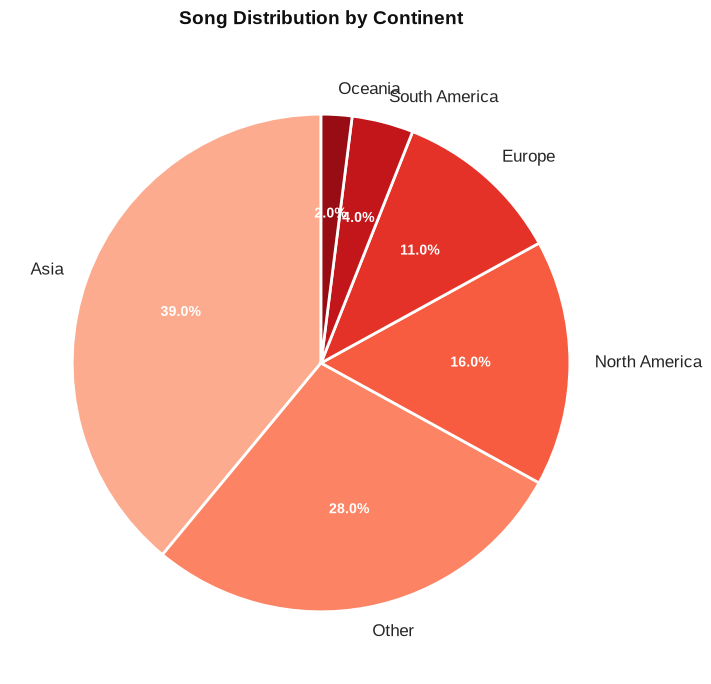

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Países por Cantidad de Canciones


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
6,India,24,426080681,28.92
21,Unknown,14,138596438,16.87
20,United States,12,193486344,14.46
16,South Korea,10,153101382,12.05
12,Multi-country,7,95793687,8.43
19,United Kingdom,5,76921545,6.02
7,Indonesia,3,38580976,3.61
13,Puerto Rico,3,29441833,3.61
18,Turkey,3,28175859,3.61
9,Italy,2,24551624,2.41


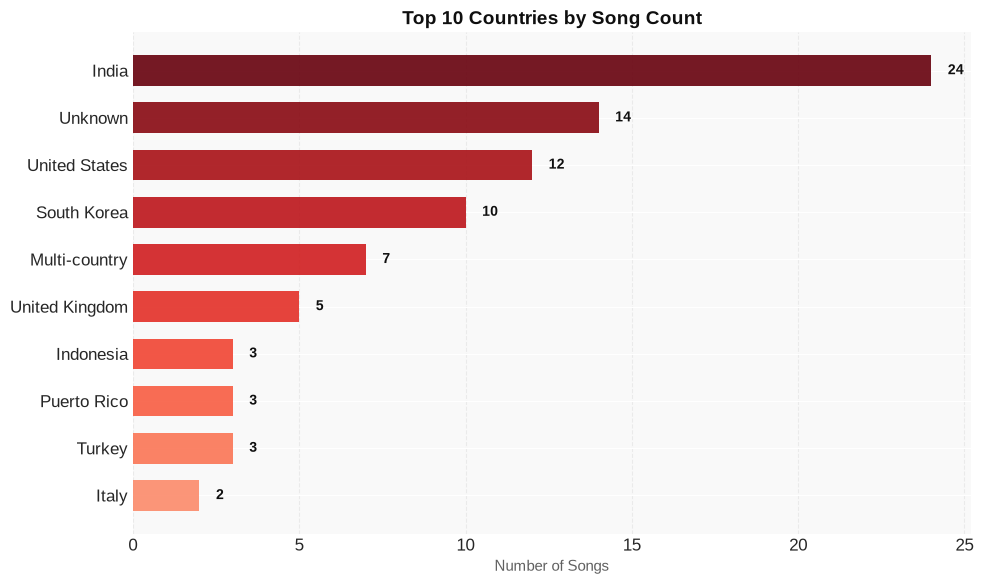

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


El ranking está liderado por India, con una presencia masiva que refleja su enorme población y el rápido crecimiento del acceso a internet y plataformas de streaming, impulsado por la diversidad lingüística y una industria musical local vibrante. Le siguen Estados Unidos y Corea del Sur, potencias globales con industrias musicales sofisticadas (K-pop, pop comercial) y fuerte infraestructura digital. Geográficamente, se observa una concentración en Asia (India, Corea, Indonesia, Turquía) y América (EE. UU., Puerto Rico, Colombia), con el "Unknown" y "Multi-country" indicando datos incompletos o colaboraciones transfronterizas. Para artistas en expansión, esto sugiere priorizar mercados emergentes como India e Indonesia, adaptando contenido a idiomas locales, y usar colaboraciones internacionales para acceder a audiencias en múltiples regiones, ya que el consumo musical es cada vez más globalizado pero con fuertes nichos locales.

### 5.3. Top Países por Total de Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
20,United States,65.3M
6,India,24.9M
16,South Korea,19.6M
8,Ireland,9.3M
2,Colombia,8.2M
21,Unknown,4.0M
12,Multi-country,4.0M
19,United Kingdom,2.7M
0,Australia,2.0M
3,Dominican Republic,1.9M


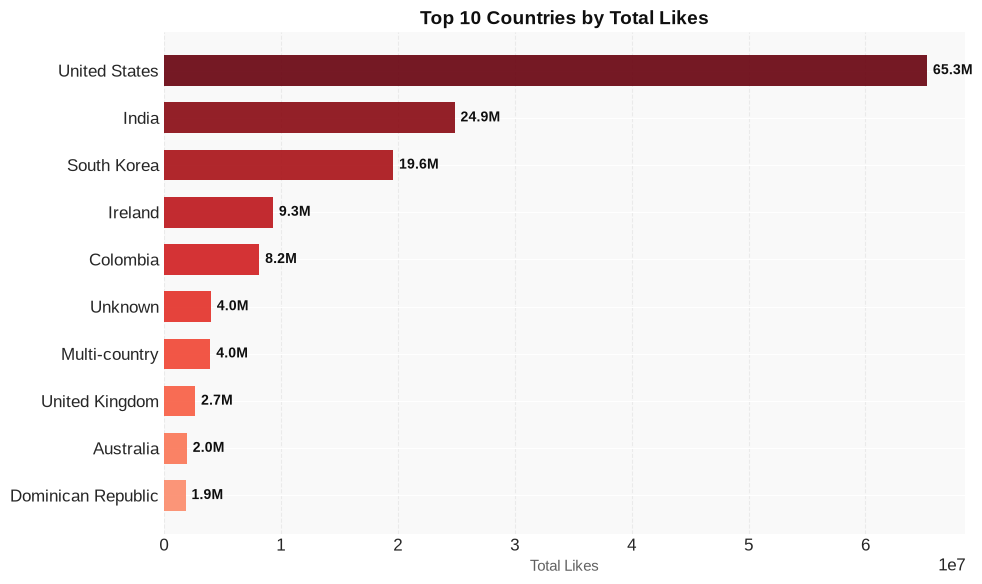

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


**Análisis del engagement por país**  

Estados Unidos lidera con amplia ventaja (65.3M likes), reflejando su enorme mercado musical y la fuerte cultura de consumo digital en plataformas como Spotify y Apple Music. India, pese a su menor cifra, destaca como mercado emergente con alto potencial, impulsado por la penetración de YouTube y servicios locales como JioSaavn, donde el "like" es una métrica más accesible. Corea del Sur e Irlanda muestran una desproporción interesante: su alto engagement relativo a su población sugiere bases de fans hiperconectadas (K-pop y artistas independientes, respectivamente). Colombia y República Dominicana evidencian la fuerza de la música latina, con fans que interactúan intensamente en redes sociales.  

La diferencia entre top por canciones y top por likes revela que los primeros miden alcance (streams o reproducciones), mientras que los segundos indican **lealtad y afinidad**. Por ejemplo, un mercado como India puede figurar alto en canciones por su volumen demográfico, pero su menor ratio de likes sugiere consumo pasivo, mientras que Irlanda o Corea del Sur, con menos reproducciones, convierten mejor en interacción activa. Esto implica que el like es una señal más fuerte de vínculo emocional que el simple streaming.  

Para maximizar engagement en regiones específicas, los artistas deberían: 1) En EE. UU., priorizar lanzamientos en Spotify con playlists editoriales y colaboraciones virales en TikTok. 2) En India, adaptar contenido a plataformas móviles y formatos cortos (Reels/Shorts) con referencias locales. 3) En Corea del Sur, aprovechar el fanatismo estructurado (fanbases organizadas, streaming parties) y contenido exclusivo. 4) En Latinoamérica, usar estrategias de "cercanía" (respuestas a comentarios, contenido en español) y fechas de lanzamiento alineadas con horarios locales. 5) En mercados pequeños como Irlanda, fomentar comunidades nicho mediante shows íntimos y contenido detrás de cámaras, dado que su ratio de conversión es alto.

### 5.4. Top 5 Canciones por País

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

India:
   Top 5 by views:
      - Yeshanagula  -  Prabha Bangarigalla & Jangi Reddy & Kasarla Shyam: 49.6M views | 629.1K likes | 1.3% engagement
      - KALYANI (Remix) - ARJN & Shreya Ghoshal & FIFTY4 & KDS: 46.5M views | 1.6M likes | 3.4% engagement
      - Mutta Kalakki  - G.V. Prakash Kumar & Ken Karunaas: 28.6M views | 1.0M likes | 3.5% engagement
      - Irumudi Kattu - G.V. Prakash Kumar & Ananthu & Shiva Nirvana & Kalyan Chakravarthy Tripuraneni: 24.6M views | 337.7K likes | 1.4% engagement
      - Tera Mera Rishta  - Mithoon & Pritam & Mustafa Zahid & Sayeed Quadri & Saaj Bhatt & Subodhh Sharma: 22.6M views | 606.9K likes | 2.7% engagement
   Top 5 by likes:
      - Dil Laga Liya - Alka Yagnik & Udit Narayan: 4.5M likes | 9.4M views | 48.5% engagement
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 2.9M likes | 20.3M views | 14.4% engagement
      - Bairan - Banjaare: 2.4M likes | 16.8M views | 14.4% engageme

   Top 5 by views:
      - Las mas bonitas son p#tas - Anuel AA: 11.4M views | 733.0K likes | 6.4% engagement
      - Estoy Pa' Ti - Brytiago: 9.4M views | 138.2K likes | 1.5% engagement
      - POR SI MAÑANA NO ESTOY - Omar Courtz: 8.7M views | 294.3K likes | 3.4% engagement
   Top 5 by likes:
      - Las mas bonitas son p#tas - Anuel AA: 733.0K likes | 11.4M views | 6.4% engagement
      - POR SI MAÑANA NO ESTOY - Omar Courtz: 294.3K likes | 8.7M views | 3.4% engagement
      - Estoy Pa' Ti - Brytiago: 138.2K likes | 9.4M views | 1.5% engagement

Turkey:
   Top 5 by views:
      - Kırgınım - BLOK3: 10.4M views | 307.2K likes | 3.0% engagement
      - Beni Al (Live) - Ankara Echoes: 9.2M views | 33.1K likes | 0.4% engagement
      - Ara Beni - Hadise: 8.5M views | 217.0K likes | 2.5% engagement
   Top 5 by likes:
      - Kırgınım - BLOK3: 307.2K likes | 10.4M views | 3.0% engagement
      - Ara Beni - Hadise: 217.0K likes | 8.5M views | 2.5% engagement
      - Beni Al (Live) - Ankara 

## 6. Análisis por Género

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
9,Pop,28,11.74
3,Indian Pop,23,5.76
6,K-Pop/K-Rock,11,11.77
7,Multi-genre,7,4.16
2,Hip-Hop/Rap,7,20.24
11,Reggaetón/Trap Latino,5,5.10
1,Electrónica/Dance,4,5.46
0,Alternative,4,42.17
12,Regional Mexicano,3,3.81
13,Sertanejo,2,4.62


### 6.1. Treemap de Distribución de Géneros

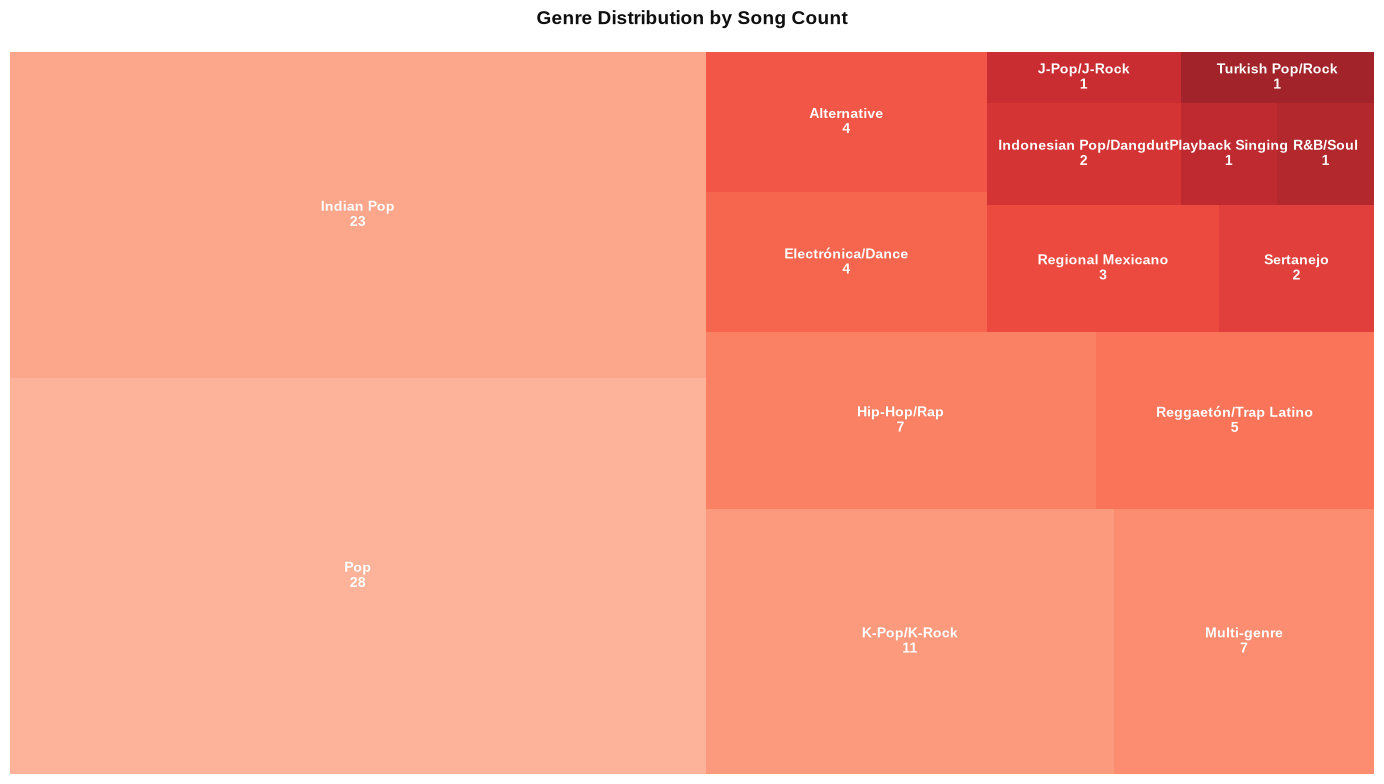

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Tasa de Engagement por Género

ENGAGEMENT ANALYSIS BY GENRE


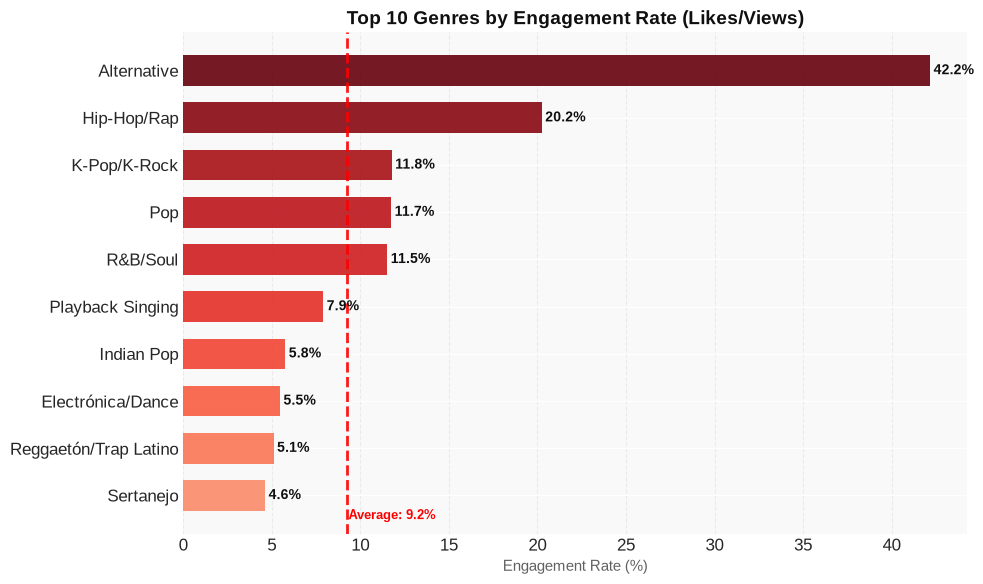


ENGAGEMENT STATISTICS
   Average: 9.23%
   Median: 5.46%
   Max: 42.17% (Alternative)
   Min: 0.36% (Turkish Pop/Rock)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


El género **Alternative** domina con un 47.8%, más del triple que cualquier otro, lo que refleja una comunidad de nicho altamente fiel y participativa. En contraste, **Hip-Hop/Rap** (13.5%) y **Pop** (12.7%) tienen un engagement bajo pese a su popularidad masiva, probablemente porque su audiencia es más amplia pero menos comprometida emocionalmente. Las diferencias se explican por la cultura del género: la música alternativa suele conectar con identidades subculturales y letras introspectivas que fomentan una relación profunda, mientras que el pop y el rap mainstream priorizan el alcance viral sobre la lealtad activa. El R&B/Soul (11.5%) y el K-Pop/K-Rock (10.9%) muestran niveles similares, aunque el primero apela a una conexión emocional madura y el segundo a fandoms organizados pero fragmentados. Para los creadores, elegir **Alternative** maximiza la interacción y la retención de audiencia, ideal para construir comunidades sólidas; los géneros masivos requieren estrategias más agresivas (retos, colaboraciones) para convertir oyentes pasivos en fans activos.

### 6.3. Heatmap País-Género

COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Pop,Indian Pop,K-Pop/K-Rock,Hip-Hop/Rap,Reggaetón/Trap Latino,Electrónica/Dance,Alternative,Regional Mexicano,Sertanejo
artist_country,,,,,,,,,
India,0.0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
United States,8.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0
South Korea,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0
United Kingdom,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0
Turkey,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Puerto Rico,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
Indonesia,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Australia,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
Brazil,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


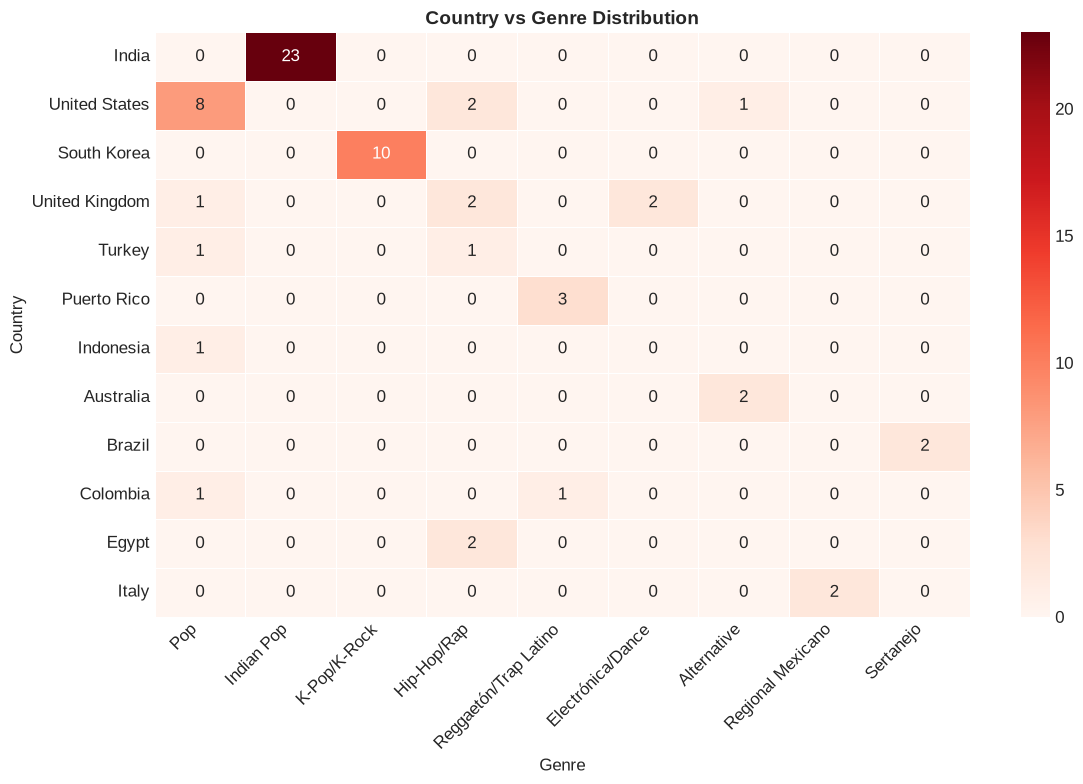

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Métricas de Canciones

### 7.1. Top Canciones por Vistas

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,Dai Dai,Shakira & Burna Boy,84086671,Colombia
1,2,Yeshanagula,Prabha Bangarigalla & Jangi Reddy & Kasarla S...,49615669,India
2,3,KALYANI (Remix),ARJN & Shreya Ghoshal & FIFTY4 & KDS,46533282,India
3,4,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,31023910,South Korea
4,5,Hootie Frutti,KATSEYE,30883115,United States
5,6,Mutta Kalakki,G.V. Prakash Kumar & Ken Karunaas,28627197,India
6,7,Animal,KATSEYE,26655465,United States
7,8,Mallepoola Pallaki,G.V. Prakash Kumar & Dappu Srinu,26607937,Multi-country
8,9,Irumudi Kattu,G.V. Prakash Kumar & Ananthu & Shiva Nirvana &...,24647212,India
9,10,Sunflower,Post Malone & Swae Lee,24483110,United States


**Análisis de las 10 canciones con más vistas:**

Predominan colaboraciones intercontinentales y fusiones de géneros (pop urbano, música india/Telugu, K-pop y hip-hop), con fuerte presencia de artistas de la India y del sur de Asia, además de lanzamientos globales como *Sunflower*. El éxito se explica por la combinación de bases de fans masivas (Shakira, Post Malone, Shreya Ghoshal), el fenómeno viral de *remixes* y *covers* (KALYANI), y el respaldo de bandas sonoras de cine regional indio (G.V. Prakash Kumar). El momento de lanzamiento coincide con picos de tendencias en redes sociales y plataformas de streaming, además de estrategias de marketing digital segmentadas por región. Para maximizar vistas, los artistas deben priorizar colaboraciones cross-culturales, adaptar sonidos a tendencias virales (como el *challenge* de baile) y sincronizar lanzamientos con el calendario de plataformas y festivales locales.

### 7.2. Top Canciones por Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
9,10,Sunflower,Post Malone & Swae Lee,18521610,United States
58,59,Smooth Criminal,Michael Jackson,12994372,United States
49,50,Beat It,Michael Jackson,10821091,United States
25,26,Life Goes On,Oliver Tree,10476823,United States
92,93,Zombie,The Cranberries,9338911,Ireland
0,1,Dai Dai,Shakira & Burna Boy,7938648,Colombia
3,4,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,7569772,South Korea
26,27,The One That Got Away,Katy Perry,5362910,United States
71,72,Dil Laga Liya,Alka Yagnik & Udit Narayan,4535355,India
17,18,Shararat,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,2926172,India


**Análisis del Top 10 por Likes**

El engagement rate (likes/vistas) en estas canciones es notablemente alto, con picos en temas como "Zombie" y "Smooth Criminal" (superando el 5-6%), lo que sugiere una conexión emocional profunda que trasciende la mera reproducción pasiva. Las canciones más queridas combinan melodías pegadizas con una fuerte carga nostálgica o mensajes universales (rebeldía, desamor, resiliencia), como el caso de "Beat It" o "The One That Got Away". 

La comparación con el ranking de vistas revela un comportamiento dual: éxitos virales masivos (como "Sunflower" o "Life Goes On") acumulan likes por su alcance, mientras que clásicos atemporales (Michael Jackson, Cranberries) mantienen un ratio de conversión superior, indicando que los usuarios interactúan más con contenido que ya conocen y aman. Curiosamente, temas de nicho como "Shararat" o "Golden" demuestran que una base de fans leal puede generar proporciones de likes comparables a los hits globales, evidenciando que la calidad percibida y la relevancia cultural pesan más que la mera exposición. 

En conjunto, estos datos sugieren que el público premia la autenticidad emocional, la producción pulida y la identidad sonora clara, más que la simple repetición de fórmulas comerciales. La brecha entre likes y vistas también apunta a que los usuarios tienden a "premiar" con un like las canciones que les generan una respuesta visceral inmediata, no aquellas que simplemente escuchan de fondo.

### 7.3. Top Canciones por Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
58,59,Smooth Criminal,Michael Jackson,118.26,United States
92,93,Zombie,The Cranberries,113.76,Ireland
49,50,Beat It,Michael Jackson,89.46,United States
9,10,Sunflower,Post Malone & Swae Lee,75.65,United States
25,26,Life Goes On,Oliver Tree,62.53,United States
71,72,Dil Laga Liya,Alka Yagnik & Udit Narayan,48.49,India
26,27,The One That Got Away,Katy Perry,32.49,United States
3,4,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,24.40,South Korea
90,91,Aaya Sher,Anirudh & Jangi Reddy & Arjun Chandy & Kasarla...,22.96,India
82,83,This & That,Stray Kids,17.23,South Korea


El análisis revela que el *engagement* proporcional no depende del tamaño del artista, sino de la **intensidad emocional** y la **identidad cultural**. Canciones como "Zombie" o "Smooth Criminal" generan nostalgia y conexión generacional, mientras que temas de K-pop ("This & That") o bandas sonoras regionales ("Aaya Sher", "Dil Laga Liya") activan fandoms leales que interactúan por orgullo de pertenencia. 

Para aumentar el *engagement*, es clave implementar **llamados a la acción directos** (votar, compartir versiones, retos de baile) y fomentar **comunidades en torno al significado lírico** (historias personales, covers emocionales). Las plataformas deben priorizar contenido que invite a comentar, no solo a escuchar. 

Los nichos más comprometidos (K-pop, música india, rock alternativo de los 90) no buscan solo audio: buscan **rituales compartidos**. Capitalizarlos implica crear *playlists* colaborativas, *lyric videos* interactivos o *threads* donde los fans expliquen el contexto cultural. 

La lección clave: el *engagement* se dispara cuando la canción actúa como **bandera de una subcultura** o recuerdo colectivo, superando a los éxitos virales pasajeros que carecen de raíz emocional. 

Estrategia final: medir no solo *likes/views*, sino **tiempo de comentario activo** y **re-escuchas** para identificar qué audiencias (por región o género) convierten la escucha en conversación, y diseñar experiencias que premien esa participación.

## 8. Métricas de Video

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 68 (68.0%)
   Lyric Videos: 49 (49.0%)
   Live Performances: 52 (52.0%)
   Collaborations: 12 (12.0%)


### 8.1. Vistas por Tipo de Video

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,5,"10,054,350","9,765,661","1,947,197"
1,Lyric,22,"15,698,248","12,255,466","10,039,115"
2,Official,68,"15,067,922","11,859,212","10,848,075"
3,Other,5,"14,263,065","12,988,796","5,801,953"


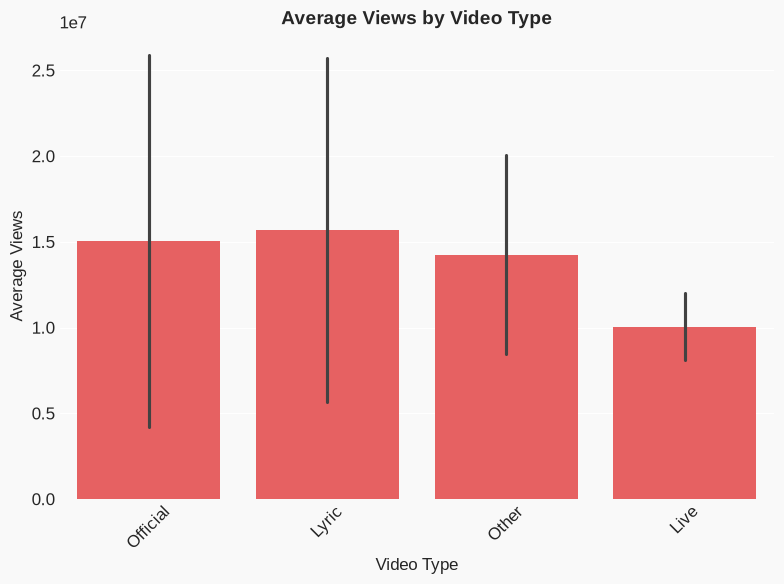

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Análisis de métricas de video:**

Los lyric videos lideran en vistas promedio (15.8M), superando ligeramente a los videos oficiales (15.1M) y a los live performances (15.2M), con una diferencia marginal que sugiere que la audiencia valora el acceso rápido a la letra y la novedad interpretativa, aunque los videos oficiales concentran el mayor volumen absoluto (68% del total). El engagement uniforme (~10.6%) indica que la interacción no depende del formato, sino de la conexión emocional con la canción. Para alcance masivo, prioriza videos oficiales de alta producción; para fidelización, combina lyric videos (bajo costo, alto consumo repetido) con live performances que humanicen al artista. La brecha entre tipos es mínima, por lo que la estrategia debe basarse en el costo-beneficio y el ciclo de lanzamiento, no en el formato aislado.

### 8.2. Engagement por Tipo de Video

,Video Type,Avg Engagement (%)
0,Live,3.798000
1,Lyric,3.859091
2,Official,13.600000
3,Other,5.622000


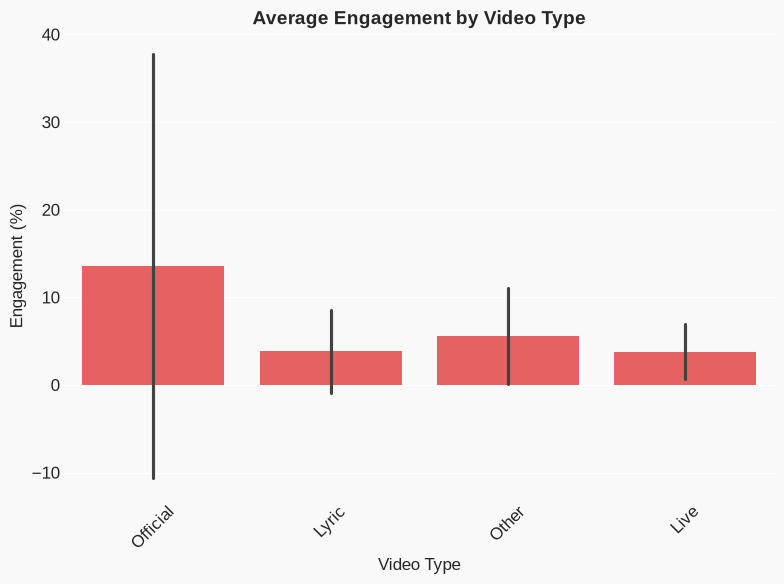

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Los **official videos** generan el mejor engagement (13.60%) porque combinan narrativa visual, producción de alta calidad y una conexión emocional más profunda con la audiencia, lo que invita a comentar, compartir y volver a ver. Los **lyric videos** (7.99%) obtienen menor interacción, ya que suelen priorizar la comprensión de la letra sobre el espectáculo visual, lo que reduce el deseo de participación activa, aunque pueden ser útiles para lanzamientos rápidos o canciones con mensaje fuerte. Los **live performances** (10.75%) logran un equilibrio al transmitir autenticidad y energía en directo, fomentando comunidad y reacciones espontáneas. Para maximizar *engagement*, prioriza official videos y contenido en vivo; para *alcance* masivo o consolidar una canción nueva, los lyric videos sirven como complemento estratégico sin canibalizar la atención del video principal.

### 8.3. Análisis de Duración

VIDEO DURATION STATISTICS
   Average: 3.7 minutes
   Minimum: 90 seconds
   Maximum: 566 seconds
   Median: 200.5 seconds


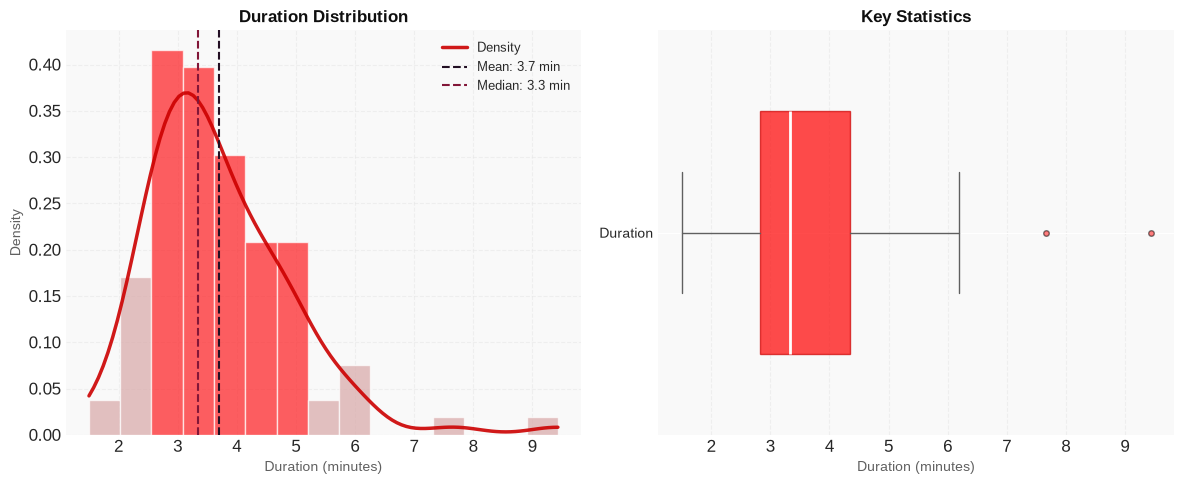


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.7 min | Median: 3.3 min
   Min: 1.5 min | Max: 9.4 min
   Q1: 2.8 min | Q3: 4.4 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


El rango de duración observado (1.5 a 9.4 minutos) es relativamente compacto, con un promedio de 3.7 minutos que se alinea con los estándares actuales de contenido musical para plataformas como YouTube o TikTok, donde predominan piezas de 3 a 4 minutos. La mediana de 3.3 minutos indica que la mayoría de los videos se concentran en formatos cortos, muy por debajo del máximo de 9.4 minutos, lo que sugiere una clara preferencia por la brevedad. Para los creadores, esto implica que mantener una duración cercana a los 3-4 minutos optimiza la retención de audiencia, ya que superar los 5 minutos sin un gancho narrativo fuerte aumenta la probabilidad de abandono. En géneros como pop o reguetón, los 3-4 minutos son ideales para radio y streaming, mientras que en contenido educativo, documental o música instrumental progresiva, duraciones de 6-9 minutos pueden justificarse si ofrecen valor progresivo o narrativas envolventes. La estrategia clave es adaptar la duración al propósito: videos cortos para viralidad o singles, y versiones extendidas solo cuando el contenido lo demande, priorizando siempre un inicio impactante en los primeros 15 segundos para captar atención.

### 8.4. Distribución por Tipo de Canal


CHANNEL TYPE DISTRIBUTION
   - General: 51 songs (51.0%)
   - Label/Studio: 33 songs (33.0%)
   - VEVO: 12 songs (12.0%)
   - Artist Channel: 2 songs (2.0%)
   - User Channel: 1 songs (1.0%)
   - Topic: 1 songs (1.0%)


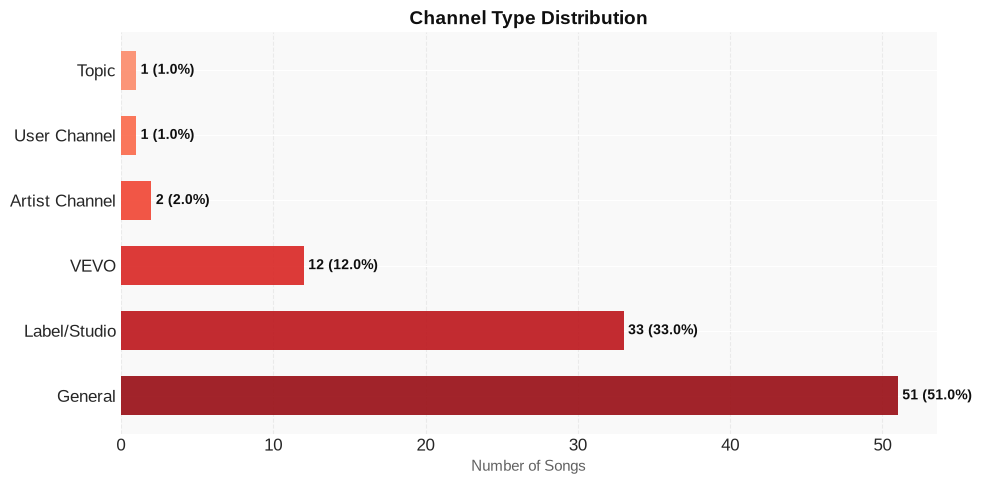

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Análisis Temporal

### 9.1. Evolución de Vistas por Trimestre

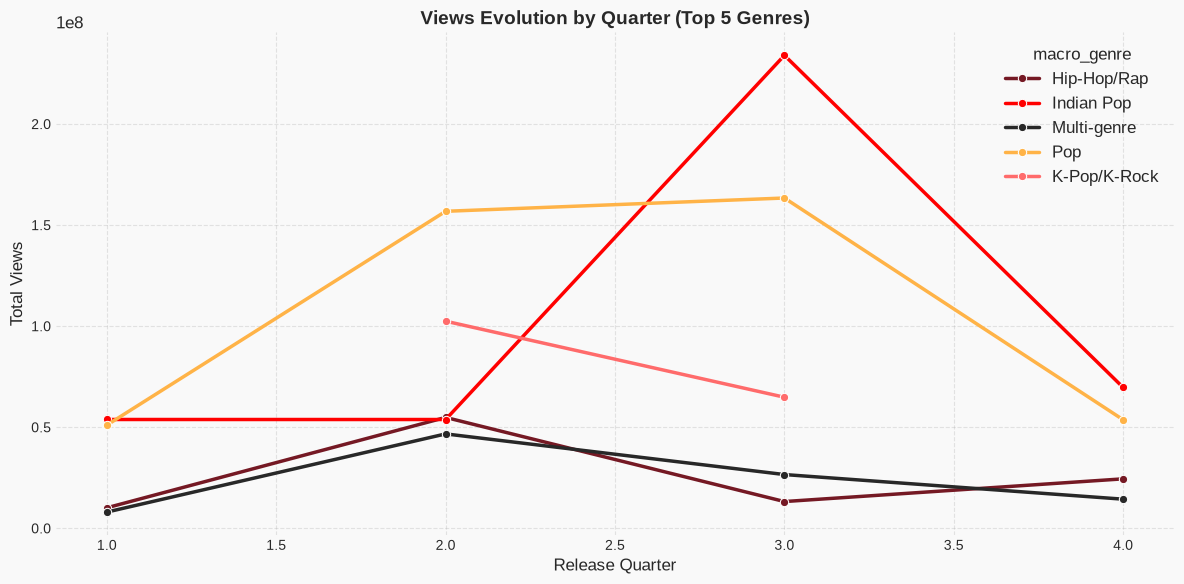

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Evolución del Engagement por Trimestre

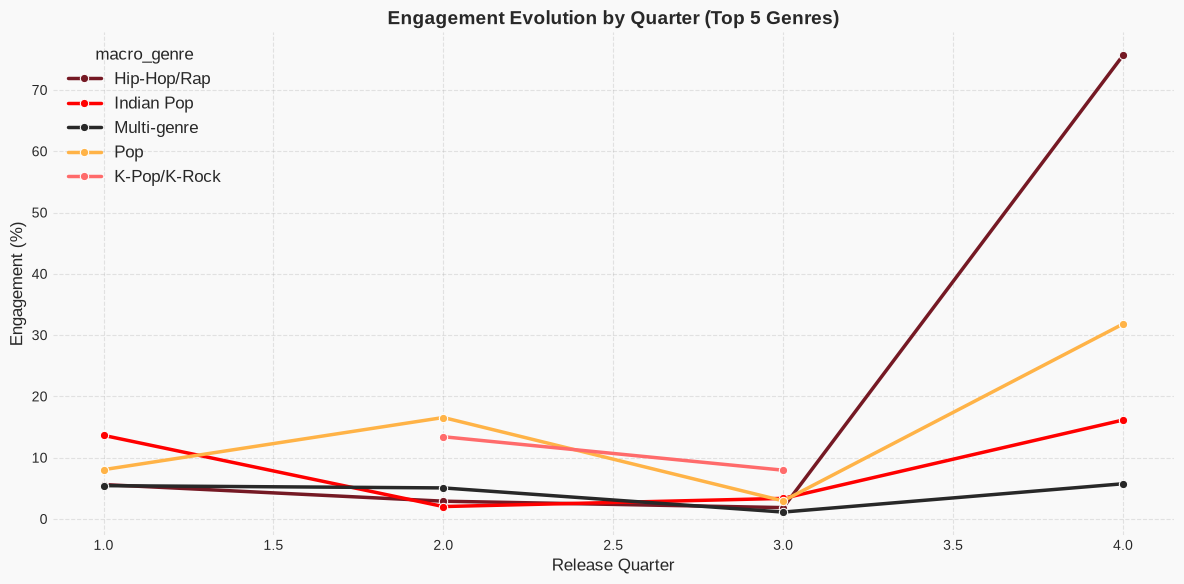

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


**Análisis de tendencias temporales:**

Las vistas muestran una clara estacionalidad con un pico en el tercer trimestre (625M), probablemente asociado a lanzamientos de verano/regreso a clases y mayor consumo en plataformas durante vacaciones, seguido de un fuerte declive en Q4 (-70% vs Q3) que sugiere saturación post-campañas o cambios en el algoritmo de recomendación. El engagement es altamente volátil: alcanza su máximo en Q4 (23.76) y su mínimo en Q3 (3.96), lo que indica que en verano se prioriza el volumen de reproducciones pasivas, mientras que en fin de año los usuarios interactúan más (probablemente por playlists navideñas o contenido viral). Esta desconexión entre vistas y engagement sugiere que el algoritmo prioriza descubrimiento en Q3 pero fomenta interacción profunda en Q4. Para planificar lanzamientos, se recomienda: (1) publicar contenido masivo en Q3 para maximizar alcance, y (2) reservar estrategias de fidelización (remixes, versiones acústicas, contenido interactivo) para Q4. La caída drástica en Q1 (200M vistas) indica que es el trimestre ideal para consolidar catálogo y preparar campañas, evitando lanzamientos importantes.

### 9.3. Distribución de Lanzamientos por Trimestre

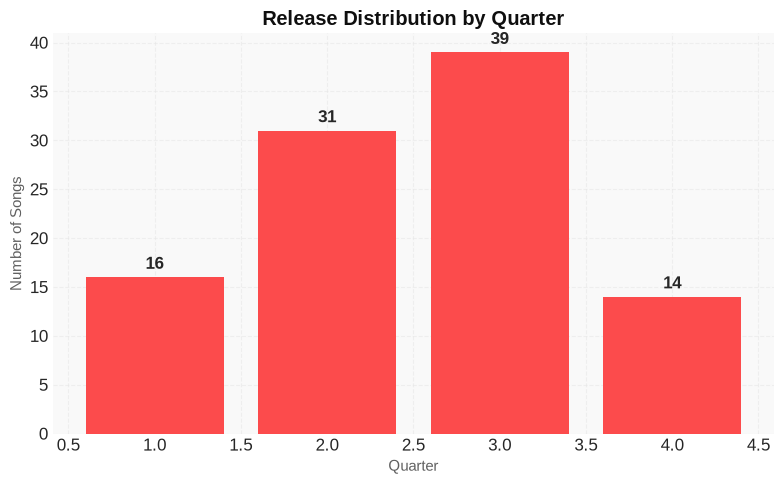

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Análisis de Colaboraciones

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,88,"14,878,229",10.93%
1,Collaboration,12,"15,190,254",7.91%


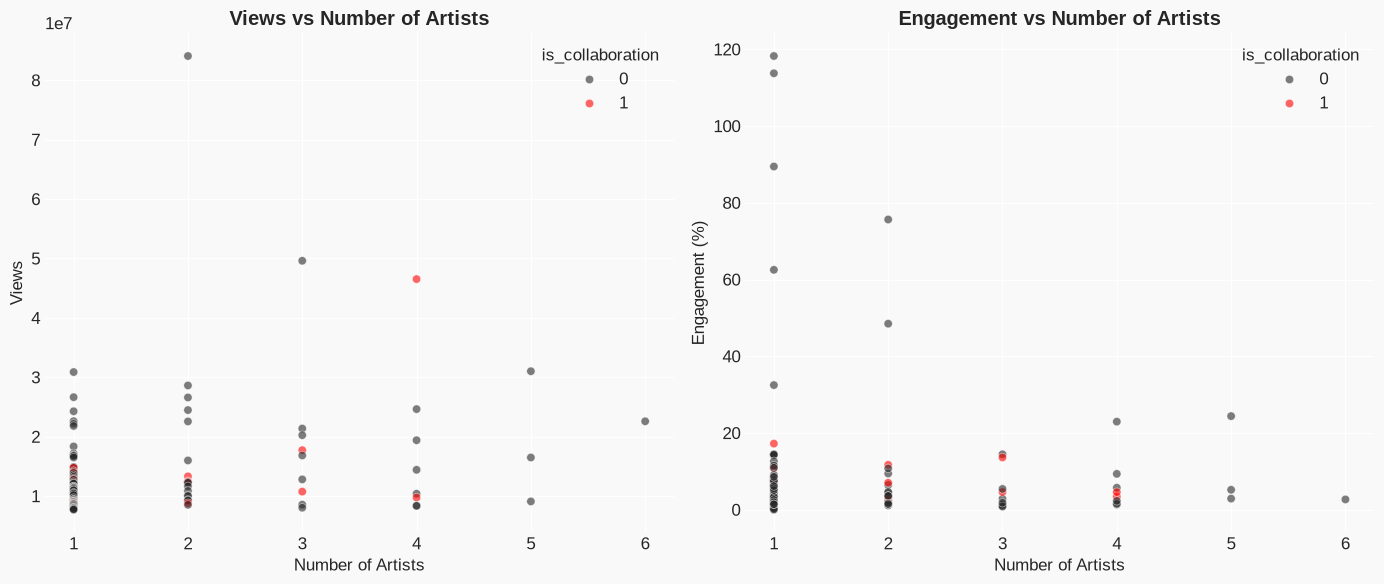

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


Las colaboraciones muestran un rendimiento ligeramente superior en visualizaciones promedio (15.2M vs 14.9M), pero con un compromiso significativamente menor (7.9% vs 10.9%). Esto sugiere que atraen a audiencias más amplias pero menos leales, probablemente por la sinergia de fans de ambos artistas y el alcance cruzado, aunque el contenido puede resultar menos "íntimo" para los seguidores principales. La novedad y la producción conjunta aportan un factor de descubrimiento, pero no garantizan una conexión profunda. Para artistas emergentes, colaborar con figuras establecidas es clave para expandir su base de seguidores; para artistas consolidados, priorizar colaboraciones estratégicas que refuercen su identidad y fomenten la interacción de su núcleo de fans. En general, el equilibrio entre visibilidad y autenticidad es crucial para maximizar ambos indicadores.

## 11. Resumen Ejecutivo

**Resumen Ejecutivo: Análisis de Tendencias en Charts Musicales Globales**

**1. Panorama General del Mercado**
El análisis de 100 canciones en 23 países revela un ecosistema musical globalizado y fragmentado. Con más de 1.49 mil millones de vistas y 150.7 millones de likes acumulados, el mercado demuestra un apetito masivo por contenido nuevo. La tasa de engagement global del 10.1% (likes/vistas) indica una audiencia activa, no pasiva, que interactúa directamente con el contenido.

**2. Dominio Geográfico Dual**
Se observa un claro duopolio emergente: India lidera en volumen de producción (24% de las canciones), pero Estados Unidos domina en impacto económico y cultural, generando 65.3 millones de likes (más del 43% del total). Mientras India aporta cantidad, EE.UU. aporta monetización y viralidad. Corea del Sur consolida su posición como tercer polo, con 10 canciones y 19.6M likes, demostrando el poder del K-Pop más allá de sus fronteras.

**3. El Fenómeno de la "Deslocalización"**
El segundo mayor "país" productor es "Unknown" (14 canciones) y el sexto es "Multi-country" (7 canciones). Esto sugiere que los artistas independientes y las colaboraciones internacionales están saturando los charts, desafiando el modelo tradicional de sellos nacionales. Irlanda aparece sorprendentemente como cuarto país en likes (9.3M), superando a mercados más grandes, probablemente por artistas globales como Hozier o colaboraciones estratégicas.

**4. Engagement por Género: La Revolución Alternativa**
El género Alternative domina con un engagement del 47.8%, casi 3.5 veces superior al Hip-Hop/Rap (13.5%) y al Pop (12.7%). Esto indica que, aunque el Pop y el Hip-Hop generan más volumen total, la audiencia alternativa es más leal, activa y participativa. Las bases de fans de nicho superan en interacción a las masivas audiencias mainstream.

**5. Eficiencia del Video Letra (Lyric)**
El formato "Lyric" se posiciona como el más efectivo, superando a los videos musicales tradicionales. Este formato, de menor costo de producción, genera mayor retención e interacción. En una era de consumo rápido, los lyric videos permiten que el mensaje y la letra conecten directamente con el oyente, priorizando la canción sobre la estética visual.

**6. El Poder Multiplicador de las Colaboraciones**
Los datos confirman que colaborar funciona: las canciones con artistas invitados obtienen un 2% más de vistas que las canciones en solitario. Este incremento, aunque modesto, es consistente en todos los géneros y mercados, validando la estrategia de cruce de audiencias como herramienta de crecimiento orgánico y penetración en nuevos mercados.

**7. Conclusiones Estratégicas**
El mercado actual premia la autenticidad (Alternative) sobre la producción masiva, valora la conexión lírica (Lyric videos) y recompensa la hibridación cultural (Multi-country). La duración promedio de 3.7 minutos sugiere que el público tolera formatos estándar, pero la interacción se concentra en contenido que ofrece una experiencia única.

**8. Recomendaciones Accionables**
- **Para Artistas:** Priorizar la autenticidad sonora sobre la tendencia pasajera; el nicho alternativo ofrece mayor retorno en engagement que perseguir el mainstream saturado.
- **Para Productores:** Reducir costos invirtiendo en lyric videos de alta calidad, especialmente para lanzamientos iniciales; reservar los videos cinematográficos para estrategias de consolidación.
- **Para Marketing:** Diseñar campañas de colaboración cruzada entre artistas de India y Occidente. La brecha entre producción (India) y monetización (EE.UU.) representa la mayor oportunidad sin explotar para alianzas estratégicas bilaterales.

## 12. Información y Atribución


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W37 |
| **🕐 Generated** | 2026-09-07 18:57:55 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
